# Team Members
1.Soham Siddhant Bidyadhar - (sb67347)

2.Agnitra Das - (ad55985)

3.Sarah Lee - (cl45274)

4.Jyoti Kumari - (jk52725)

5.Saaket Joshi - (sj778)

6.Rohan Giri - (rg52539)


In [ ]:
Write a scraper using Python to fetch messages posted in Edmunds.com discussion forums. The
scraper output should be a .csv file with the following columns: date and message (even though
you will only use the messages in your analysis). Before you develop the scraper, carefully study
one of the forums on Edmunds.com to understand the html design as well as the threading
structures.

In [446]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_edmunds_forum(url, max_posts=5000):
    # List to store data
    data = []
    
    # Headers to mimic a browser visit
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36'
    }
    
    while len(data) < max_posts:
        # Fetch the content of the page
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find all posts
        posts = soup.find_all('li', class_='Item')

        for post in posts:
            if len(data) >= max_posts:
                break
            try:
                # Extract date
                date_tag = post.find('span', class_='MItem DateCreated')
                date = date_tag.text.strip() if date_tag else 'No Date Available'

                # Extract message text
                message_div = post.find('div', class_='Message userContent')
                message = message_div.text.strip() if message_div else 'No Message Available'

                # Add to data list
                data.append({'date': date, 'message': message})
            except Exception as e:
                print(f"Error processing post: {e}")
                continue

        # Find the next page link
        next_button = soup.find('a', class_='Next')
        if next_button:
            url = next_button['href']
        else:
            break

        # Sleep to avoid overwhelming the server
        time.sleep(2)  # Adjust the sleep time if necessary

    # Create a DataFrame and save to CSV
    df = pd.DataFrame(data)
    df.to_csv('edmunds_forum_posts.csv', index=False)

if __name__ == "__main__":
    url = 'https://forums.edmunds.com/discussion/2864/general/x/entry-level-luxury-performance-sedans'
    scrape_edmunds_forum(url)

## Task A:
Once you fetch the data, test if the data support Zipf’s law econometrically. Additionally plot the
most common 100 words in the data against the theoretical prediction of the law. For this question, do
not remove stopwords. Also do not perform stemming or lemmatization.
Check http://www.garysieling.com/blog/exploring-zipfs-law-with-python-nltk-scipy-and-matplotlib
(Note that the above link does NOT test Zipf’s law econometrically)

In [47]:
import csv
import re
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from sklearn.manifold import MDS
from collections import defaultdict, Counter

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\girir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Input filename
input_filename = 'edmunds_forum_posts.csv'  # Input file

# Step 1: Extract sentences without removing stopwords
def extract_sentences_no_preprocessing(file):
    """
    Extracts text data from the second column of the CSV file without removing stopwords,
    splitting it into sentences and tokenizing without additional preprocessing.
    """
    sentences = []
    
    with open(file, mode='r', encoding='utf-8') as infile:
        reader = csv.reader(infile)
        
        for row in reader:
            # Assuming the text to process is in the second column (index 1)
            text = row[1]

            # Split the text into sentences based on punctuation (.?!)
            sentences += re.split(r'[.!?]', text)

    print(f"Step 1 Complete: Extracted {len(sentences)} sentences.\n")
    return sentences

# Run the sentence extraction step
sentences = extract_sentences_no_preprocessing(input_filename)

In [49]:

# Step 2: Tokenize and count word frequencies
def calculate_word_frequencies_no_preprocessing(sentences):
    """
    Calculates the frequency of each word in the given list of sentences, 
    without removing stopwords or performing any preprocessing.
    """
    word_freq = defaultdict(int)
    
    for sentence in sentences:
        # Tokenize by splitting on whitespace
        words = sentence.split()
        
        # Count word frequencies
        for word in words:
            word_freq[word] += 1
    
    print("Step 2 Complete: Calculated word frequencies.\n")
    return word_freq

# Run the word frequency calculation
word_freq = calculate_word_frequencies_no_preprocessing(sentences)

Step 2 Complete: Calculated word frequencies.



In [53]:
# Step 3A: Display top 100 most frequent words
def display_top_100_words(word_freq):
    """
    Displays the top 100 most frequent words.
    """
    # Sort words by frequency (most common first)
    sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
    
    # Extract top 100 words and their frequencies
    top_100_words = sorted_word_freq[:100]
    
    # Display the top 100 words and their frequencies
    print("Top 100 Most Frequent Words:")
    for i, (word, freq) in enumerate(top_100_words, 1):
        print(f"{i}. {word}: {freq}")
    
    return top_100_words

# Run the function to display top 100 words
top_100_words = display_top_100_words(word_freq)

Top 100 Most Frequent Words:
1. the: 24174
2. a: 11676
3. and: 9953
4. to: 9686
5. I: 9340
6. is: 7290
7. of: 6995
8. in: 6277
9. that: 5514
10. it: 4665
11. you: 4285
12. for: 4261
13. with: 3725
14. car: 3387
15. on: 3226
16. have: 3044
17. not: 2963
18. are: 2887
19. but: 2764
20. my: 2568
21. as: 2514
22. be: 2489
23. The: 2309
24. or: 2066
25. was: 2015
26. at: 1778
27. about: 1769
28. cars: 1752
29. they: 1703
30. more: 1693
31. like: 1686
32. this: 1632
33. than: 1623
34. an: 1575
35. all: 1542
36. BMW: 1510
37. TL: 1470
38. has: 1445
39. can: 1417
40. would: 1380
41. will: 1379
42. one: 1360
43. just: 1315
44. if: 1294
45. me: 1285
46. 3: 1269
47. what: 1258
48. get: 1257
49. -: 1235
50. out: 1233
51. your: 1179
52. think: 1175
53. from: 1157
54. so: 1095
55. do: 1082
56. don't: 1077
57. G35: 1031
58. it's: 1022
59. better: 896
60. up: 881
61. when: 880
62. by: 868
63. drive: 863
64. I'm: 862
65. had: 853
66. much: 850
67. there: 844
68. some: 838
69. new: 833
70. no: 831
71. o

In [55]:
# Step 3B: Test Zipf's Law econometrically (separate from displaying top 100 words)
def test_zipf_law_econometrically(top_100_words):
    """
    Tests Zipf's law econometrically by regressing log(frequency) on log(rank).
    """
    # Get ranks and frequencies for the econometric test
    ranks = np.array(list(range(1, len(top_100_words) + 1)))  # Rank from 1 to 100
    frequencies = np.array([freq for word, freq in top_100_words])  # Corresponding frequencies
    
    # Log-transform ranks and frequencies
    log_ranks = np.log(ranks)
    log_frequencies = np.log(frequencies)
    
    # Add a constant for the regression
    X = sm.add_constant(log_ranks)
    model = sm.OLS(log_frequencies, X)
    results = model.fit()
    
    # Print regression summary
    print("\nZipf's Law Econometric Test Results:\n")
    print(results.summary())
    
    return log_ranks, log_frequencies, results

# Run the regression to test Zipf's Law
log_ranks, log_frequencies, results = test_zipf_law_econometrically(top_100_words)



Zipf's Law Econometric Test Results:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     9031.
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           2.61e-98
Time:                        15:23:53   Log-Likelihood:                 107.14
No. Observations:                 100   AIC:                            -210.3
Df Residuals:                      98   BIC:                            -205.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

doesn't Fall in the confidence 95 % -2sigma to + 2 sigma

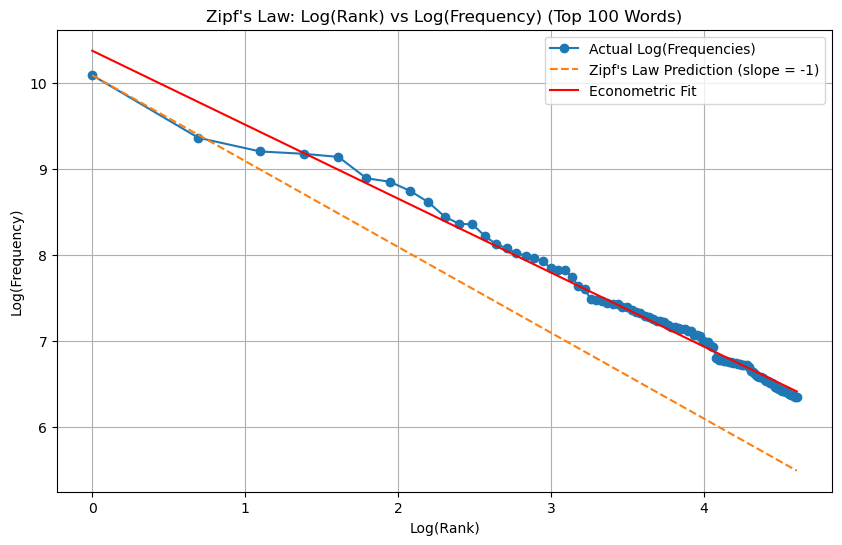


Step 4 Complete: Plot generated and displayed.



In [58]:
# Step 4: Plot the results
def plot_zipf_law(log_ranks, log_frequencies, results):
    """
    Plots the econometric test results and compares the actual top 100 word frequencies 
    with Zipf's Law prediction.
    """
    # Plot the actual log-rank vs log-frequency plot
    plt.figure(figsize=(10, 6))
    plt.plot(log_ranks, log_frequencies, label="Actual Log(Frequencies)", marker='o')
    
    # Plot the Zipf's Law prediction (slope of -1)
    theoretical_line = -1 * log_ranks + log_frequencies[0]
    plt.plot(log_ranks, theoretical_line, label="Zipf's Law Prediction (slope = -1)", linestyle='--')
    
    # Plot the econometric fit line
    predicted_log_frequencies = results.predict(sm.add_constant(log_ranks))
    plt.plot(log_ranks, predicted_log_frequencies, label="Econometric Fit", linestyle='-', color='red')
    
    # Add labels and grid to the plot
    plt.title("Zipf's Law: Log(Rank) vs Log(Frequency) (Top 100 Words)")
    plt.xlabel("Log(Rank)")
    plt.ylabel("Log(Frequency)")
    plt.legend()
    plt.grid(True)
    
    # Display the plot
    plt.show()
    
    print("\nStep 4 Complete: Plot generated and displayed.\n")

# Plot the results of the Zipf's Law test
plot_zipf_law(log_ranks, log_frequencies, results)

## Task B:
Find the top 10 brands from frequency counts. You will need to write a script to count the
frequencies of words (stopwords should NOT be counted). Replace frequently occurring car models with
brands so that from now on you have to deal with only brands and not models. You will need another
script for this job. A list of model and brand names (not exhaustive) are provided in a separate file. Even
if a brand (e.g., BMW) is mentioned multiple times in a message, it should be counted as 1.

In [61]:
df = pd.read_csv("edmunds_forum_posts.csv")

In [63]:
def clean(comment):
    cleaned_comment = re.sub("[^\w\s]", " ", comment)
    cleaned_comment = cleaned_comment.replace("\n"," ")
    return cleaned_comment.lower()

In [65]:
df["message"] = df["message"].astype(str).map(clean)

In [67]:
# replacing models with make
make_model = pd.read_csv("car_models_and_brands_v1.csv")
make_model.drop_duplicates(inplace=True)
dictionary = dict(zip(make_model['Model'], make_model['Brand']))
def model_to_make(comment):
    words = comment.split()
    words1 = []
    for i in words:
        if i in dictionary.keys():
            words1.append(dictionary[i])
        else:
            words1.append(i)
    comment1 = " ".join(words1)
    return comment1
df["message"] = df["message"].map(model_to_make)

# considering unique words in a comment so that brands are counted once per comment
def unique_in_comment(comment):
    words = comment.split()
    words = list(set(words))
    comment1 = " ".join(words)
    return comment1
df["message"] = df["message"].map(unique_in_comment)

In [69]:
#removing stopwords
all_words = " ".join(df["message"])
word_list = all_words.split()
word_list = [i for i in word_list if i not in stop_words]

In [71]:
# creating the word-frequency dataframe
from collections import Counter
freq = Counter(word_list)
word = []
frequency = []
for item, count in freq.items():
    word.append(item)
    frequency.append(count)
df1 = pd.DataFrame({"Word":word,"Frequency":frequency})
df1.sort_values(by="Frequency",ascending=False,inplace=True)
df1.reset_index(drop=True,inplace=True)
df1.head()

,Word,Frequency
0,bmw,2608
1,car,2020
2,acura,1272
3,like,1261
4,cars,1245


# Task C:
Calculate lift ratios for associations between the top-10 brands identified in Task A. You will have 
to write a script to do this task). For lift calculations, be sure not to count a mention more than onc 
per post, even if it is mentioned multiple times in the post. In your code, ensure that a message is n t
counted in the lift calculations if the mentions of two brands are separated by more than, say, 5 o  7
words.


In [75]:
# Top 10 brands obtained from Task B
brands = ["bmw", "acura", "honda", "audi", "infiniti", "lexus", "toyota", "nissan", "subaru", "volkswagen", "mercedes"] 


In [77]:
df = pd.read_csv("edmunds_forum_posts.csv")
stop_words = set(stopwords.words('english'))

In [79]:
# cleaning comments and coverting to lowercase
def clean(comment):
    cleaned_comment = re.sub("[^\w\s]", " ", comment)
    cleaned_comment = cleaned_comment.replace("\n"," ")
    word_list = cleaned_comment.split()
    cleaned_comment = " ".join(word_list)
    return cleaned_comment.lower()

df["message"] = df["message"].astype(str).map(clean)

In [81]:
#replacing models with make
make_model = pd.read_csv("car_models_and_brands_v1.csv")
make_model.drop_duplicates(inplace=True)
dictionary = dict(zip(make_model['Model'], make_model['Brand']))
def model_to_make(comment):
    words = comment.split()
    words1 = []
    for i in words:
        if i in dictionary.keys():
            words1.append(dictionary[i])
        else:
            words1.append(i)
    comment1 = " ".join(words1)
    return comment1
df["message"] = df["message"].map(model_to_make)

In [83]:
# creating a co_occurance_matrix
co_occurrence_matrix = pd.DataFrame(0, index=brands, columns=brands)

In [85]:
# specifying the co-occurance criteria (no counted if 2 brands in a comment are apart by more than 7 words)
for comment in df["message"]:
    words = comment.split()
    for brand1 in brands:
        if brand1 in words:
            b1_indices = [index for index, value in enumerate(words) if value == brand1]
            sur_words = set()  # using a set of surrounding words to avoid duplicates
            for k in b1_indices:
                # defining the window so that indices stay within bounds
                start = max(0, k - 7)
                end = min(len(words), k + 8)
                # adding the surrounding words to the set
                sur_words.update(words[start:end])
            for brand2 in brands:
                if brand2 in sur_words:
                    co_occurrence_matrix.loc[brand1, brand2] += 1

In [86]:
co_occurrence_matrix

,bmw,acura,honda,audi,infiniti,lexus,toyota,nissan,subaru,volkswagen,mercedes
bmw,2608,389,87,225,358,120,55,60,49,41,67
acura,389,1272,106,59,300,72,21,38,19,5,11
honda,87,106,457,7,24,9,92,53,7,8,4
audi,225,59,7,440,52,23,6,4,10,46,22
infiniti,358,300,24,52,1033,70,9,56,16,4,12
lexus,120,72,9,23,70,346,29,7,5,2,21
toyota,55,21,92,6,9,29,330,51,3,7,6
nissan,60,38,53,4,56,7,51,316,8,4,1
subaru,49,19,7,10,16,5,3,8,213,3,0
volkswagen,41,5,8,46,4,2,7,4,3,163,8


In [89]:
# creating the lift_matrix
lift_matrix = pd.DataFrame(0, index=brands, columns=brands)
total_comments = len(df)

In [91]:
# filling the created lif_matrix
for brand1 in brands:
    for brand2 in brands:
        lift_matrix.loc[brand1,brand2] = (total_comments * co_occurrence_matrix.loc[brand1,brand2])/(co_occurrence_matrix.loc[brand1,brand1] * co_occurrence_matrix.loc[brand2,brand2])

In [93]:
# showing lift values
lift_matrix_show = lift_matrix.copy()
for i in range(0,len(lift_matrix_show)):
    for j in range(0,i+1):
        lift_matrix_show.iloc[i,j] = ""
lift_matrix_show

,bmw,acura,honda,audi,infiniti,lexus,toyota,nissan,subaru,volkswagen,mercedes
bmw,,0.586307,0.364977,0.980375,0.664424,0.664917,0.31953,0.364021,0.441041,0.482235,0.721634
acura,,,0.911743,0.527087,1.141573,0.817974,0.250143,0.472693,0.350636,0.120577,0.242916
honda,,,,0.17406,0.254194,0.28459,3.050196,1.835028,0.359561,0.536978,0.245863
audi,,,,,0.572032,0.755386,0.206612,0.143843,0.533504,3.206916,1.404494
infiniti,,,,,,0.979246,0.132007,0.85777,0.363588,0.11878,0.32631
lexus,,,,,,,1.269925,0.320114,0.339222,0.177311,1.704878
toyota,,,,,,,,2.445339,0.213402,0.650679,0.510725
nissan,,,,,,,,,0.594283,0.388289,0.088892
subaru,,,,,,,,,,0.43204,0.0
volkswagen,,,,,,,,,,,1.378645


In [95]:
lift_matrix.to_csv("Lifts.csv",index=False)

In [97]:
# replacing zeros in the lift_matrix so that no value in dissimilarity matrix is infinity
lift_matrix = lift_matrix.replace(0,0.01)

In [99]:
dissimilarity_matrix = 1/lift_matrix
dissimilarity_matrix.to_csv("Dissimilarity.csv",index=False)

# Task D: 
Show the brands on a multi-dimensional scaling (MDS) map.

In [102]:
dissimilarity_matrix = pd.read_csv("Dissimilarity.csv")

In [104]:
# asssiging row indices to the dissimilarity matrix
dissimilarity_matrix.index = dissimilarity_matrix.columns


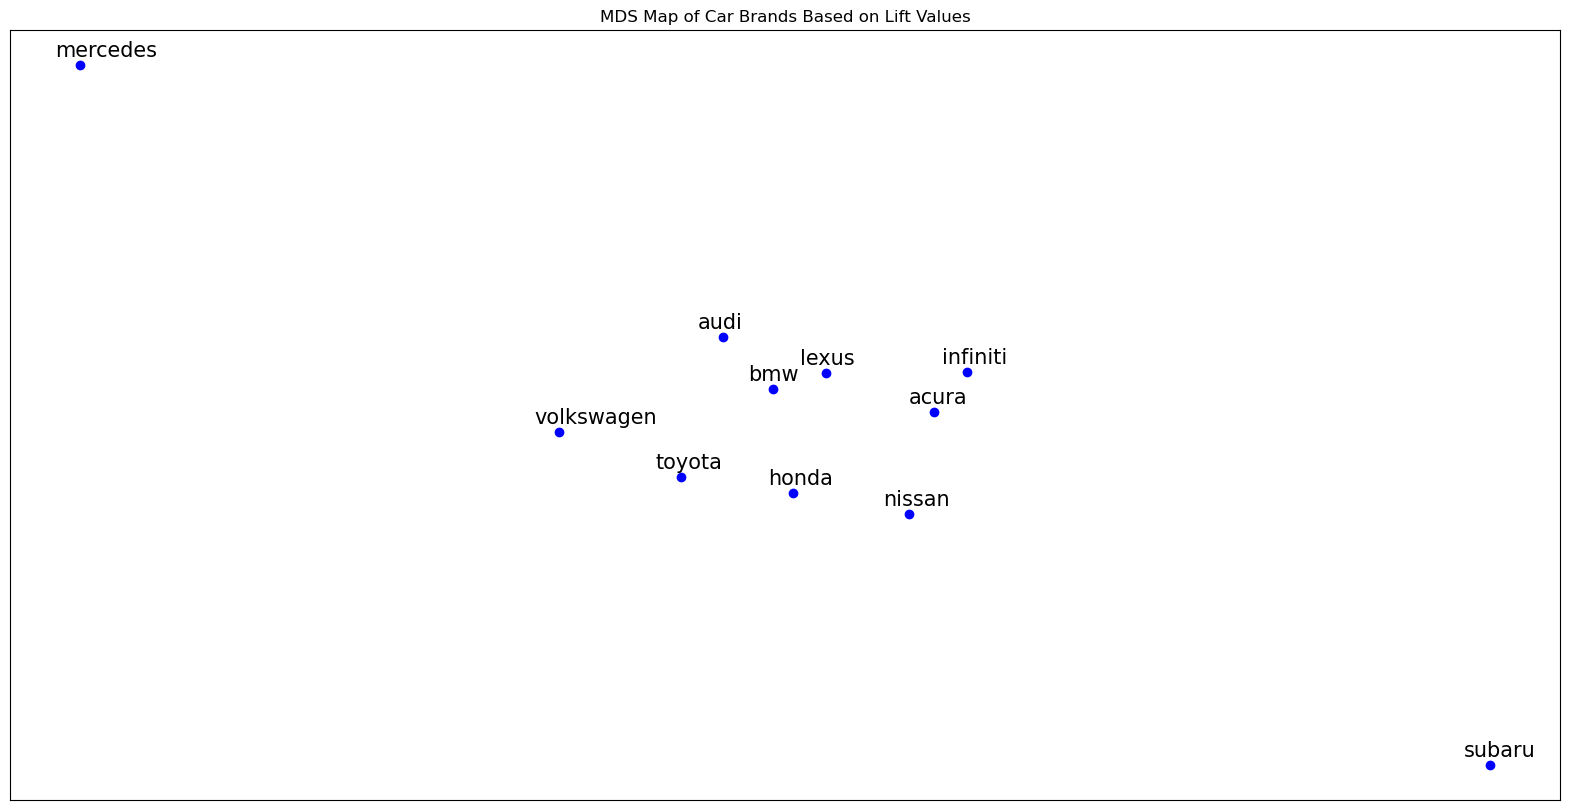

In [106]:
# running the MDS function from sklearn.manifold
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
mds_coordinates = mds.fit_transform(dissimilarity_matrix)

# plotting the MDS map
plt.figure(figsize=(20, 10))
plt.scatter(mds_coordinates[:, 0], mds_coordinates[:, 1], color='blue')
for i, brand in enumerate(dissimilarity_matrix.index):
    plt.text(mds_coordinates[i, 0]-0.3, mds_coordinates[i, 1]+0.19, brand, fontsize=15)

plt.title('MDS Map of Car Brands Based on Lift Values')
plt.xticks([])
plt.yticks([])

# # drawing ellipses cluster brands manually
# from matplotlib.patches import Ellipse
# ellipse1 = Ellipse(xy=(0, -1.4), width=4, height=2.7, edgecolor='red', facecolor='none', linestyle='dotted', linewidth=2)
# plt.gca().add_patch(ellipse1)

# ellipse2 = Ellipse(xy=(-0.25, 1.7), width=2, height=3, edgecolor='red', facecolor='none', linestyle='dotted', linewidth=2)
# plt.gca().add_patch(ellipse2)

# ellipse3 = Ellipse(xy=(2.1, 0.9), width=2, height=2, edgecolor='red', facecolor='none', linestyle='dotted', linewidth=2)
# plt.gca().add_patch(ellipse3)

plt.show()

# Part E:
What insights can you offer to your client from your analyses in Tasks C and D?

### Insights from the Co-occurrence Matrix:
BMW and Lexus co-occur 120 times in consumer conversations, indicating that these two brands are frequently compared. This suggests that consumers may view them as direct competitors, particularly in the entry-level luxury segment.

High lift ratios between brands such as Audi ,  BMW and Mercedes likely indicate strong competitive dynamics in the entry-level luxury market. Consumers are cross-shopping between these brands, meaning they are perceived to offer similar value propositions or product features.

### Insights from the lift matrix
We can see the strength of the association between the brands. Volkswagen and Audi have a high lift value of 3.20, suggesting that consumers who are loyal to Volkswagen are more likely to consider Audi as an alternative. This could indicate strong brand overlap in terms of consumer preference, especially since both brands share a parent company and similar design philosophies.

Lexus and Mercedes have a relatively lower lift value, indicating that consumers may not frequently consider them together.This suggests that consumers loyal to one brand may not often cross-shop between these two, likely because of distinct brand positioning—Lexus focuses on comfort and value, while Mercedes emphasizes premium luxury.

### Cross-Brand Opportunities:
Brands that are not traditionally direct competitors but have high lift ratios (e.g., Honda and Acura might indicate cross-market opportunities. These brands may be able to capture consumers from different segments by emphasizing certain product features or qualities.

### Cluster of Premium Competitors:
BMW, Audi, and Lexus are tightly clustered in the MDS plot, indicating strong similarities in consumer perceptions. This suggests that consumers often compare these brands when shopping for luxury cars. 



## Task F
What are 5 most frequently mentioned attributes or features of cars in the discussions? Which
attributes are most strongly associated with which of these 5 brands? There is no need to plot the MDS
plot for this questi in.n a table.

In [112]:
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords

# Load your dataset (assuming df['message'] contains the comments)
df = pd.read_csv('edmunds_forum_posts.csv')

# List of car-related attributes to track
car_attributes = ['performance', 'luxury', 'engine', 'price', 'handling', 'comfort', 'design', 'safety', 'fuel', 'technology']

# Define stop words to filter out common words
stop_words = set(stopwords.words('english'))

# Function to clean and process text
def clean_text(text):
    if isinstance(text, float):  # Handle non-string values
        return []
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower()  # Convert to lowercase
    words = text.split()  # Tokenize the text
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return words

# Convert the message column to string type and handle missing values
df['message'] = df['message'].astype(str).fillna('')

# Apply the clean_text function to each comment
df['Processed'] = df['message'].apply(clean_text)

# Initialize a counter to track attribute mentions
attribute_counts = Counter()

# Loop through each processed comment and count the attributes
for comment in df['Processed']:
    for word in comment:
        if word in car_attributes:
            attribute_counts[word] += 1

# Get the 5 most frequently mentioned attributes
most_common_attributes = attribute_counts.most_common(5)

# Display the results
print("Top 5 most frequently mentioned car attributes:")
for attribute, count in most_common_attributes:
    print(f"{attribute.capitalize()} ({count} mentions)")


Top 5 most frequently mentioned car attributes:
Performance (892 mentions)
Luxury (678 mentions)
Engine (600 mentions)
Price (504 mentions)
Handling (471 mentions)


In [114]:

# Function to clean comments and convert to lowercase
def clean(comment):
    cleaned_comment = re.sub("[^\w\s]", " ", comment)
    cleaned_comment = cleaned_comment.replace("\n"," ")
    word_list = cleaned_comment.split()
    cleaned_comment = " ".join(word_list)
    return cleaned_comment.lower()

df["message"] = df["message"].astype(str).map(clean)

# Loading car models and brands dataset, creating a dictionary for model-to-brand mapping
make_model = pd.read_csv("car_models_and_brands.csv")
make_model.drop_duplicates(inplace=True)
dictionary = dict(zip(make_model['Model'], make_model['Brand']))

# Function to replace car models with their brands
def model_to_make(comment):
    words = comment.split()
    words1 = []
    for i in words:
        if i in dictionary.keys():
            words1.append(dictionary[i])
        else:
            words1.append(i)
    return " ".join(words1)

df["message"] = df["message"].map(model_to_make)

# List of car brands to include in the co-occurrence matrix
#brands = list(make_model['Brand'].unique())

# List of aspirational keywords
frequent_attributes = ['performance', 'luxury', 'engine', 'price', 'handling']

# Creating a co-occurrence matrix for brands and aspiration words
co_occurrence_matrix2 = pd.DataFrame(0, index=brands, columns=frequent_attributes)

# Populating the co-occurrence matrix with criteria that two words (brands or aspirational keywords)
# must be within 7 words of each other
for comment in df["message"]:
    words = comment.split()
    for brand in brands:
        if brand in words:
            brand_indices = [index for index, value in enumerate(words) if value == brand]
            sur_words = set()  # set of surrounding words to avoid duplicates
            for k in brand_indices:
                # Defining the window for surrounding words (7 before and after)
                start = max(0, k - 7)
                end = min(len(words), k + 8)
                sur_words.update(words[start:end])
            for word in frequent_attributes:
                if word in sur_words:
                    co_occurrence_matrix2.loc[brand, word] += 1

# Display the co-occurrence matrix
co_occurrence_matrix2

,performance,luxury,engine,price,handling
bmw,151,62,141,90,87
acura,45,54,26,33,38
honda,9,13,7,14,3
audi,10,15,16,6,10
infiniti,43,24,19,38,25
lexus,5,16,3,6,2
toyota,13,20,6,7,14
nissan,5,10,11,5,1
subaru,16,24,2,3,5
volkswagen,3,6,2,0,1


### Task G :
What advice will you give to your client from Task F?

**BMW**: Should continue to highlight its focus on performance and driving dynamics, as these are critical factors in consumer perceptions.

**Acura**: Emphasize handling and maneuverability in marketing efforts. Position Acura as a luxury brand that delivers a refined driving experience.

**Audi**: Focus on engine technology and innovation, leveraging its strength in engine performance to attract performance-focused consumers.

**Lexus**: Double down on luxury, reinforcing its position as a brand known for comfort, refinement, and prestige.

**Infiniti**: Continue positioning itself around handling, highlighting how its vehicles provide a dynamic and responsive driving experience.
.


In [136]:
aspiration_keywords = ['want', 'buy', 'own', 'dream', 'aspire', 'wish', 'aim']

aspiration_keywords1 = ['want to', 'aim to', 'wish to', 'to buy', 'to own', 'dream of', 'aspire to']

# Creating a co-occurrence matrix for brands and aspiration words
co_occurrence_matrix1 = pd.DataFrame(0, index=brands, columns=aspiration_keywords1)

# Populating the co-occurrence matrix with criteria that two words (brands or aspirational keywords)
# must be within 7 words of each other
for comment in df["message"]:
    words = comment.split()
    for brand in brands:
        if brand in words:
            brand_indices = [index for index, value in enumerate(words) if value == brand]
            sur_words = set()  # set of surrounding words to avoid duplicates
            for k in brand_indices:
                # Defining the window for surrounding words (7 before and after)
                start = max(0, k)
                end = min(len(words), k)
                sur_words.update(words[start:end])
            for word in aspiration_keywords1:
                if word in sur_words:
                    co_occurrence_matrix1.loc[brand, word] += 1

# Apply the clean_text function to each comment and generate bigrams
df['Processed_Bigrams'] = df['message'].apply(lambda x: list(bigrams(clean_text(x))))

# Display the co-occurrence matrix
co_occurrence_matrix1

,want to,aim to,wish to,to buy,to own,dream of,aspire to
bmw,0,0,0,0,0,0,0
acura,0,0,0,0,0,0,0
honda,0,0,0,0,0,0,0
audi,0,0,0,0,0,0,0
infiniti,0,0,0,0,0,0,0
lexus,0,0,0,0,0,0,0
toyota,0,0,0,0,0,0,0
nissan,0,0,0,0,0,0,0
subaru,0,0,0,0,0,0,0
volkswagen,0,0,0,0,0,0,0


In [134]:
import pandas as pd
import re
import nltk
from nltk import bigrams
from nltk.corpus import stopwords

# Ensure NLTK stopwords are downloaded (if not already)
nltk.download('stopwords')

# Define the brands and aspirational keywords
brands = ["bmw", "acura", "honda", "audi", "infiniti", "lexus", "toyota", "nissan", "subaru", "volkswagen", "mercedes"]
aspiration_keywords1 = ['want to', 'aim to', 'wish to', 'to buy', 'to own', 'dream of', 'aspire to']

# Function to clean and process text
def clean_text(text):
    if isinstance(text, float):  # Handle non-string values
        return []
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower()  # Convert to lowercase
    words = text.split()  # Tokenize the text
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return words

# Convert the message column to string type and handle missing values
df['message'] = df['message'].astype(str).fillna('')

# Apply the clean_text function to each comment and generate bigrams
df['Processed_Bigrams'] = df['message'].apply(lambda x: list(bigrams(clean_text(x))))

# Initialize a co-occurrence matrix for brands and aspiration bigrams
co_occurrence_matrix1 = pd.DataFrame(0, index=brands, columns=aspiration_keywords1)

# Loop through each processed comment with bigrams and count brand-aspiration bigram co-occurrences
for bigram_list in df['Processed_Bigrams']:
    bigram_strings = [' '.join(bigram) for bigram in bigram_list]  # Convert bigrams to string format
    for brand in brands:
        if any(brand in bigram for bigram in bigram_strings):  # Check if any bigram contains the brand
            for aspiration in aspiration_keywords1:
                if aspiration in bigram_strings:
                    co_occurrence_matrix1.loc[brand, aspiration] += 1

# Display the co-occurrence matrix
print(co_occurrence_matrix1)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\girir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


            want to  aim to  wish to  to buy  to own  dream of  aspire to
bmw               0       0        0       0       0         0          0
acura             0       0        0       0       0         0          0
honda             0       0        0       0       0         0          0
audi              0       0        0       0       0         0          0
infiniti          0       0        0       0       0         0          0
lexus             0       0        0       0       0         0          0
toyota            0       0        0       0       0         0          0
nissan            0       0        0       0       0         0          0
subaru            0       0        0       0       0         0          0
volkswagen        0       0        0       0       0         0          0
mercedes          0       0        0       0       0         0          0
